In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
#from torchvision import datasets, transforms, utils
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.model_selection import ParameterSampler, RandomizedSearchCV, cross_val_score
#from scipy.stats import uniform
from retriever import *
import random
np.random.seed(32)
random.seed(32)
import skopt
from skopt import gp_minimize
from sklearn.model_selection import ParameterSampler, cross_val_score

### Bayesian optimization

In [95]:
#Setup

altitude_range = (14.688672, 15.181072)
latitude_range = (54.5, 55.327825)

domain = {
    "latitude": latitude_range,
    "altitude": altitude_range,
}

x0 = [np.random.choice(latitude_range),np.random.choice(altitude_range)]
y0 = request_elevation(x0[0],x0[1])

In [96]:
import csv

# Load points from CSV
points = []
with open("/Users/keremozemre/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/active_machine_learning/week1/02463 Active machine learning and agency, Spring 2026 - 232026 - 157 PM/Active-Machine-Learning-Elevation/vald/elevation_data.csv", newline="") as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        lat, lon = float(row[0]), float(row[1])
        points.append([lat, lon])

points = np.array(points)  # shape (N, 2)

# Create an iterator so we can consume points in order
points_iter = iter(points)

In [99]:
i = 0  # counter

def objective_function(x):
    """
    x: a 2-element list or array from gp_minimize, e.g., [lat, lon]
    """
    global i
    x = np.array(x)

    # Find the closest CSV point
    distances = np.linalg.norm(points - x, axis=1)
    nearest_idx = np.argmin(distances)
    nearest_point = points[nearest_idx]

    elevation = request_elevation(nearest_point[0], nearest_point[1])
    i += 1
    print(f"\n\nindex = {i}, suggested x = {x}, snapped to CSV point = {nearest_point}, elevation = {elevation}")

    return -elevation  # negative because we want to maximize


np.int = int #numpy np.int deprecation workaround

opt = gp_minimize(objective_function, # the function to minimize
                  [latitude_range, altitude_range],
                                      # the bounds on each dimension of x
                  acq_func="EI",      # the acquisition function
                  n_initial_points=0, # no initial point except the one
                  n_calls=99,         # the number of evaluations of objective_function 19 since we give one initial point
                  x0=x0,           #initial point
                  y0=[y0],           #inital objective function value
                  xi=0.1,             #exploration parameter
                  noise=0.01**2)       # the noise level (optional)



index = 1, suggested x = [54.5      14.688672], snapped to CSV point = [54.963728 14.688672], elevation = -18


index = 2, suggested x = [55.32067236 15.10773233], snapped to CSV point = [55.29023657 15.1302379 ], elevation = -74.66181182861328


index = 3, suggested x = [55.32173505 15.17992529], snapped to CSV point = [55.32512414 15.17741939], elevation = 0.9481009840965271


index = 4, suggested x = [54.58251437 15.16402849], snapped to CSV point = [55.05621904 14.81375567], elevation = 28.86093330383301


index = 5, suggested x = [54.5        15.17385155], snapped to CSV point = [55.031747   14.78066001], elevation = -5.881157398223877


index = 6, suggested x = [55.31172802 15.15687596], snapped to CSV point = [55.31056807 15.15773395], elevation = -43.05397415161133


index = 7, suggested x = [54.64315338 15.15682086], snapped to CSV point = [55.07420844 14.83808429], elevation = 58.98044204711914


index = 8, suggested x = [54.72056637 15.1483566 ], snapped to CSV point = [55

In [100]:
y_bo = np.maximum.accumulate(-opt.func_vals).ravel()
y_bo

array([ -0.        ,  -0.        ,  -0.        ,   0.94810098,
        28.8609333 ,  28.8609333 ,  28.8609333 ,  58.98044205,
        73.        , 114.32987976, 114.32987976, 122.23038483,
       122.23038483, 122.83570862, 122.83570862, 149.9315033 ,
       149.9315033 , 153.2172699 , 153.2172699 , 153.2172699 ,
       153.2172699 , 153.2172699 , 164.1272583 , 164.1272583 ,
       164.1272583 , 164.1272583 , 164.1272583 , 164.1272583 ,
       164.1272583 , 164.1272583 , 164.1272583 , 164.1272583 ,
       165.48129272, 165.48129272, 165.48129272, 165.48129272,
       165.48129272, 165.48129272, 165.48129272, 165.48129272,
       165.48129272, 165.48129272, 165.48129272, 165.48129272,
       165.48129272, 165.48129272, 165.48129272, 165.48129272,
       165.48129272, 165.48129272, 165.48129272, 165.48129272,
       165.48129272, 165.48129272, 165.48129272, 165.48129272,
       165.48129272, 165.48129272, 165.48129272, 165.48129272,
       165.48129272, 165.48129272, 165.48129272, 165.57

In [101]:
-opt.func_vals.ravel()

array([ -0.        , -18.        , -74.66181183,   0.94810098,
        28.8609333 ,  -5.8811574 , -43.05397415,  58.98044205,
        73.        , 114.32987976,  81.10462952, 122.23038483,
       108.19078827, 122.83570862,  76.80944824, 149.9315033 ,
        78.51676941, 153.2172699 ,  -0.        ,  73.02733612,
        -8.36182785, -18.        , 164.1272583 , 159.45272827,
        73.40409851, 116.38182068, 163.61805725, 110.79458618,
       157.82827759, 116.05357361, 102.52445984, 113.09214783,
       165.48129272, 158.65403748,  73.64073181, 120.90398407,
       153.2172699 , 111.83539581, 114.72369385, 118.10131073,
       144.15895081, 142.48774719, 140.89533997, 163.76551819,
       109.        , 130.28433228, 127.48696899, 112.78316498,
        78.92743683,  94.02478027, 109.5269165 , 118.98203278,
        90.21549225,  75.        , 108.63342285, 117.95793152,
        -4.28193998, 118.07372284, -18.        , -13.78739738,
       113.1807785 , 114.08573151, 114.73297882, 165.57

In [102]:
altitude_range = (14.688672, 15.181072)
latitude_range = (54.963728, 55.327825)

domain = {
    "latitude": uniform(loc=latitude_range[0], scale=latitude_range[1] - latitude_range[0]),  # full latitude_range
    "altitude": uniform(loc=altitude_range[0], scale=altitude_range[1] - altitude_range[0]),        # full altitude_range
}

param_list = list(ParameterSampler(domain,n_iter=100,random_state=32))
print(param_list)

[{'altitude': np.float64(15.111589075215093), 'latitude': np.float64(55.09943101339304)}, {'altitude': np.float64(14.96201741028651), 'latitude': np.float64(55.31167968251825)}, {'altitude': np.float64(15.051408110060727), 'latitude': np.float64(55.260905842535436)}, {'altitude': np.float64(14.738447022295967), 'latitude': np.float64(55.30178772097132)}, {'altitude': np.float64(14.98859735481132), 'latitude': np.float64(55.18093131643217)}, {'altitude': np.float64(14.73386650797365), 'latitude': np.float64(55.08940927562875)}, {'altitude': np.float64(15.015011342416583), 'latitude': np.float64(55.12455455600827)}, {'altitude': np.float64(14.960224586020386), 'latitude': np.float64(55.21994760699113)}, {'altitude': np.float64(14.978893166292867), 'latitude': np.float64(54.98190836790493)}, {'altitude': np.float64(14.965298301983895), 'latitude': np.float64(55.24275682071603)}, {'altitude': np.float64(15.137203261528406), 'latitude': np.float64(54.99755623291387)}, {'altitude': np.float6

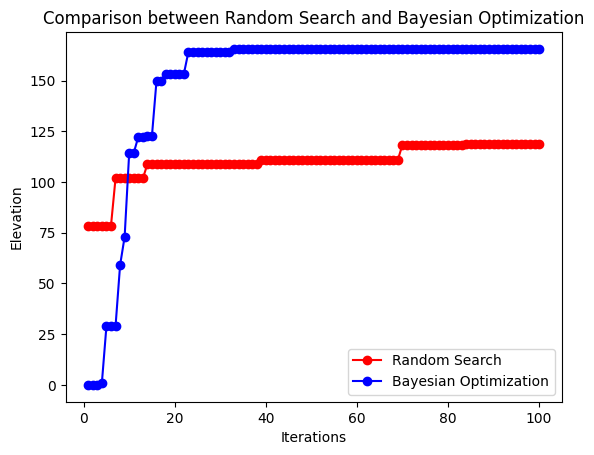

In [103]:
random_elevation = []
for param in param_list:
    random_elevation.append(request_elevation(param["latitude"],param["altitude"]))

max_cumulative_elevation_per_iteration = np.maximum.accumulate(random_elevation)
y_bo = np.maximum.accumulate(-opt.func_vals).ravel()
# define iteration number
xs = np.arange(1,len(random_elevation) + 1,1)


plt.plot(xs, max_cumulative_elevation_per_iteration, 'o-', color = 'red', label='Random Search')
plt.plot(xs, y_bo, 'o-', color = 'blue', label='Bayesian Optimization')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Elevation')
plt.title('Comparison between Random Search and Bayesian Optimization')
plt.show()

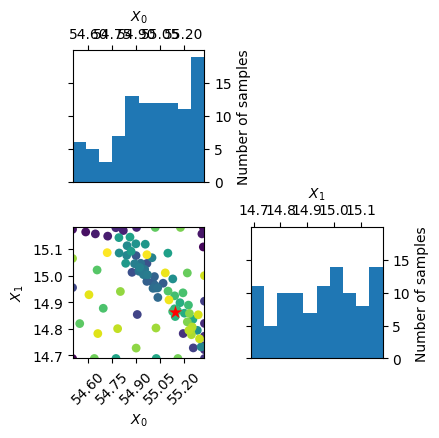

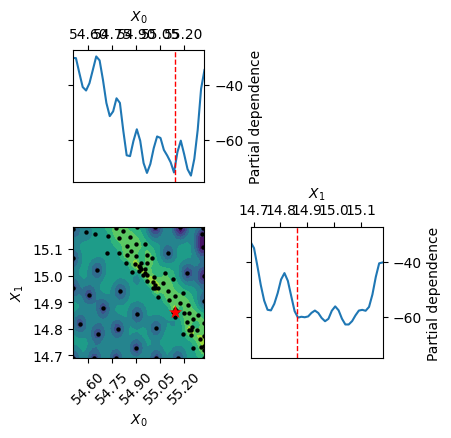

In [104]:
from skopt.plots import plot_objective, plot_evaluations

# 1. Shows where the optimizer spent most of its time
plot_evaluations(opt, bins=10)
plt.show()

# 2. Shows the predicted landscape (the surrogate model)
plot_objective(opt)
plt.show()

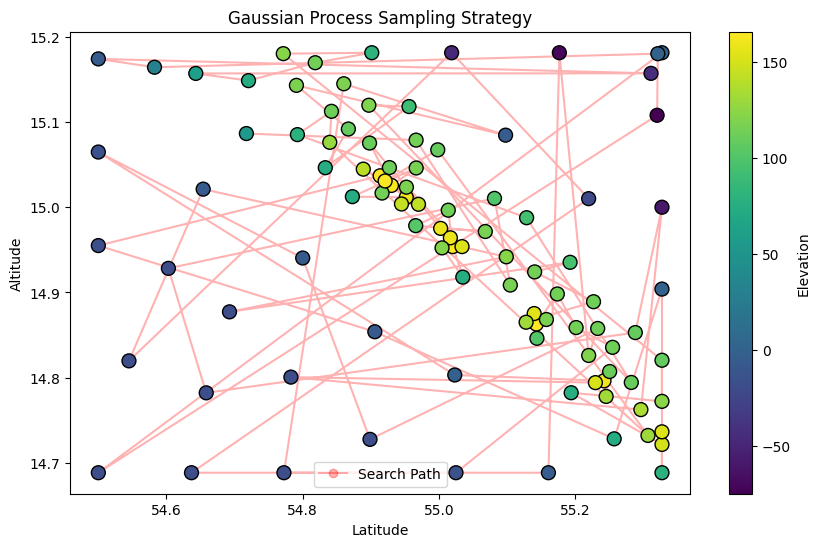

In [105]:
import matplotlib.pyplot as plt

# Extract the points sampled (x) and the results (y)
# opt.x_iters is a list of [lat, alt] pairs
# opt.func_vals is the elevation (negative because of the objective function)
sampled_points = np.array(opt.x_iters)
elevations = -opt.func_vals  # Convert back to positive elevation

plt.figure(figsize=(10, 6))
# Plot the path of the optimizer
plt.plot(sampled_points[:, 0], sampled_points[:, 1], 'ro-', alpha=0.3, label='Search Path')
# Scatter plot colored by elevation to see where the high points are
sc = plt.scatter(sampled_points[:, 0], sampled_points[:, 1], 
                 c=elevations, cmap='viridis', s=100, edgecolors='k', zorder=5)

plt.colorbar(sc, label='Elevation')
plt.xlabel('Latitude')
plt.ylabel('Altitude')
plt.title('Gaussian Process Sampling Strategy')
plt.legend()
plt.show()